In [11]:
import pandas as pd
import sqlite3

# Step 1: Load the CSV file
df = pd.read_csv('Details.csv')

# (Optional but recommended) Strip whitespace from column names
df.columns = df.columns.str.strip()

# Step 2: Connect to SQLite (creates 'my_database.db' if it doesn't exist)
conn = sqlite3.connect('my_database.db')

# Step 3: Write the DataFrame to a new SQLite table (e.g., 'details')
df.to_sql('details', conn, if_exists='replace', index=False)

# Step 4: Verify that it was inserted
result = pd.read_sql_query("SELECT * FROM details LIMIT 5", conn)
print(result)

# Step 5: Optional — check column names
print(df.columns.tolist())


  Order ID  Amount  Profit  Quantity     Category      Sub-Category  \
0  B-25681    1096     658         7  Electronics  Electronic Games   
1  B-26055    5729      64        14    Furniture            Chairs   
2  B-25955    2927     146         8    Furniture         Bookcases   
3  B-26093    2847     712         8  Electronics          Printers   
4  B-25602    2617    1151         4  Electronics            Phones   

   PaymentMode  
0          COD  
1          EMI  
2          EMI  
3  Credit Card  
4  Credit Card  
['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode']


In [15]:

query = """
SELECT 
    category, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * amount) AS revenue 
FROM details
GROUP BY category
"""
result = pd.read_sql_query(query, conn)

print(result)


      Category  total_qty  revenue
0     Clothing       3516   687654
1  Electronics       1154   818583
2    Furniture        945   665765


In [17]:
import pandas as pd
df = pd.read_sql_query(query, conn)
print ("connected successfully")


connected successfully


<Axes: xlabel='Category'>

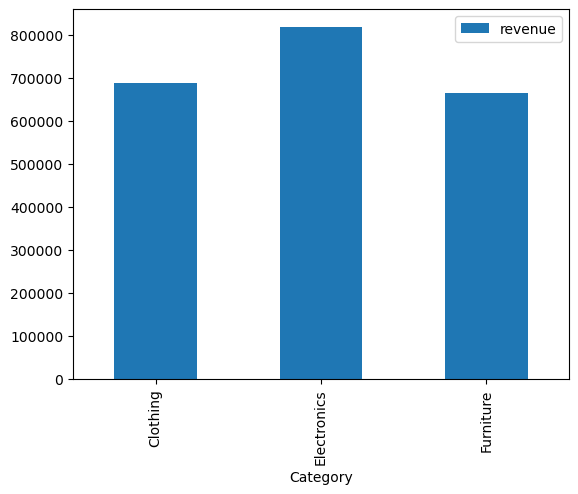

In [26]:
df.plot(kind='bar', x='Category', y='revenue')


<Axes: title={'center': 'Area Chart: Revenue by Category'}, xlabel='Category'>

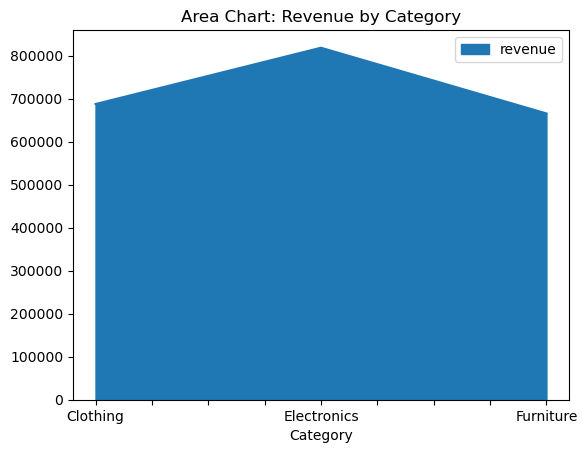

In [27]:
df.plot(kind='area', x='Category', y='revenue', title='Area Chart: Revenue by Category')


<Axes: title={'center': 'Pie Chart: Revenue Share by Category'}, ylabel='revenue'>

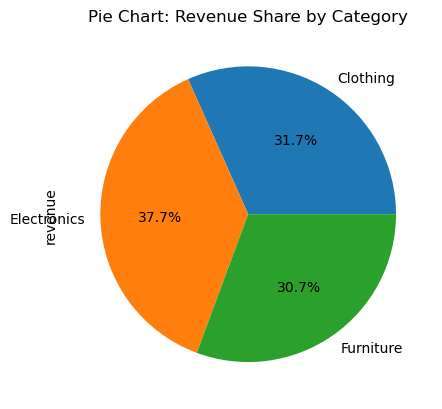

In [28]:
df_grouped = df.groupby('Category')['revenue'].sum()
df_grouped.plot(kind='pie', autopct='%1.1f%%', title='Pie Chart: Revenue Share by Category')
